In [17]:
# Importar bibliotecas

import tensorflow as tf
from tensorflow.keras.models import load_model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [18]:
# Configurações de caminhos

MODEL_PATH = "C:/Matheus/tech_challenge_fase4/models/lstm_close_price.h5"
SCALER_PATH = "C:/Matheus/tech_challenge_fase4/models/scaler.pkl"
TEST_DATA_PATH = "C:/Matheus/tech_challenge_fase4/data/raw/AAPL.csv"

In [19]:
# Carregar modelo e scaler

import joblib

model = load_model(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)
print("Min:", scaler.min_)
print("Scale:", scaler.scale_)
print("Data min original:", scaler.data_min_)
print("Data max original:", scaler.data_max_)


Min: [-5.89366623]
Scale: [0.02673479]
Data min original: [220.44934082]
Data max original: [257.85379028]


In [20]:
# Carregar dados de teste

df_test = pd.read_csv(TEST_DATA_PATH)
# Ajuste a coluna de acordo com sua feature alvo
target_col = 'Close'
values = df_test[[target_col]].values

df_test = df_test.drop([0, 1]).reset_index(drop=True)
df_test[[target_col]] = df_test[[target_col]].astype(float)
values = df_test[[target_col]].values
print(values)

[[220.44934082]
 [224.50650024]
 [228.25538635]
 [227.75819397]
 [226.27653503]
 [230.0055542 ]
 [232.54127502]
 [230.48284912]
 [230.8507843 ]
 [233.68482971]
 [235.15655518]
 [234.54003906]
 [229.46856689]
 [229.27964783]
 [230.1149292 ]
 [232.09378052]
 [232.36228943]
 [228.81225586]
 [224.64570618]
 [221.66249084]
 [220.76753235]
 [222.19947815]
 [221.47355652]
 [226.20692444]
 [225.93814087]
 [223.22042847]
 [223.22042847]
 [224.10643005]
 [227.19247437]
 [223.98695374]
 [226.99337769]
 [227.25219727]
 [227.96894836]
 [227.49111938]
 [228.83503723]
 [231.8215332 ]
 [234.00166321]
 [233.87225342]
 [236.26145935]
 [238.51126099]
 [241.55749512]
 [241.9158783 ]
 [241.94573975]
 [241.74662781]
 [245.63903809]
 [246.65444946]
 [245.38018799]
 [246.84358215]
 [247.01281738]
 [249.90969849]
 [252.33872986]
 [246.93318176]
 [248.66534424]
 [253.34420776]
 [254.12068176]
 [257.0375061 ]
 [257.85379028]
 [254.4392395 ]
 [251.06451416]
 [249.29251099]]


In [21]:
# Pré-processamento para LSTM

# Escalar os dados
values_scaled = scaler.transform(values)
print(values_scaled)

# Ajustar shape para LSTM: (samples, timesteps, features)
X_test_scaled = values_scaled.reshape((values_scaled.shape[0], 1, values_scaled.shape[1]))

[[0.        ]
 [0.10846729]
 [0.20869297]
 [0.19540063]
 [0.1557888 ]
 [0.25548333]
 [0.32327529]
 [0.26824371]
 [0.27808038]
 [0.35384798]
 [0.39319425]
 [0.37671182]
 [0.24112709]
 [0.23607638]
 [0.25840745]
 [0.31131162]
 [0.31849015]
 [0.22358075]
 [0.11218894]
 [0.03243331]
 [0.00850678]
 [0.04678955]
 [0.02738219]
 [0.15392777]
 [0.1467419 ]
 [0.07408444]
 [0.07408444]
 [0.0977715 ]
 [0.18027624]
 [0.09457733]
 [0.17495343]
 [0.18187292]
 [0.20103511]
 [0.18826045]
 [0.22418981]
 [0.30403314]
 [0.36231846]
 [0.35885871]
 [0.42273363]
 [0.48288159]
 [0.56432202]
 [0.57390331]
 [0.57470165]
 [0.56937844]
 [0.6734412 ]
 [0.70058801]
 [0.6665209 ]
 [0.70564443]
 [0.7101689 ]
 [0.7876164 ]
 [0.85255603]
 [0.70803985]
 [0.75434885]
 [0.87943727]
 [0.90019614]
 [0.97817682]
 [1.        ]
 [0.90871271]
 [0.81849015]
 [0.77111602]]


In [22]:
# Fazer previsões

y_pred_scaled = model.predict(X_test_scaled)

# Desescalar
y_pred = scaler.inverse_transform(y_pred_scaled)
print(y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
[[221.7752 ]
 [221.86855]
 [221.9556 ]
 [221.944  ]
 [221.90955]
 [221.99649]
 [222.05605]
 [222.00768]
 [222.01631]
 [222.083  ]
 [222.11778]
 [222.10321]
 [221.98393]
 [221.9795 ]
 [221.99907]
 [222.0455 ]
 [222.05182]
 [221.9686 ]
 [221.87175]
 [221.80301]
 [221.7825 ]
 [221.81535]
 [221.79868]
 [221.90794]
 [221.9017 ]
 [221.83887]
 [221.83887]
 [221.8593 ]
 [221.93085]
 [221.85654]
 [221.92621]
 [221.93224]
 [221.94893]
 [221.93777]
 [221.96913]
 [222.03911]
 [222.09047]
 [222.08742]
 [222.14398]
 [222.19746]
 [222.27025]
 [222.27885]
 [222.27957]
 [222.27478]
 [222.36842]
 [222.39294]
 [222.36218]
 [222.3975 ]
 [222.40161]
 [222.47183]
 [222.53094]
 [222.39969]
 [222.44162]
 [222.55548]
 [222.57445]
 [222.64587]
 [222.66592]
 [222.58224]
 [222.49991]
 [222.45683]]


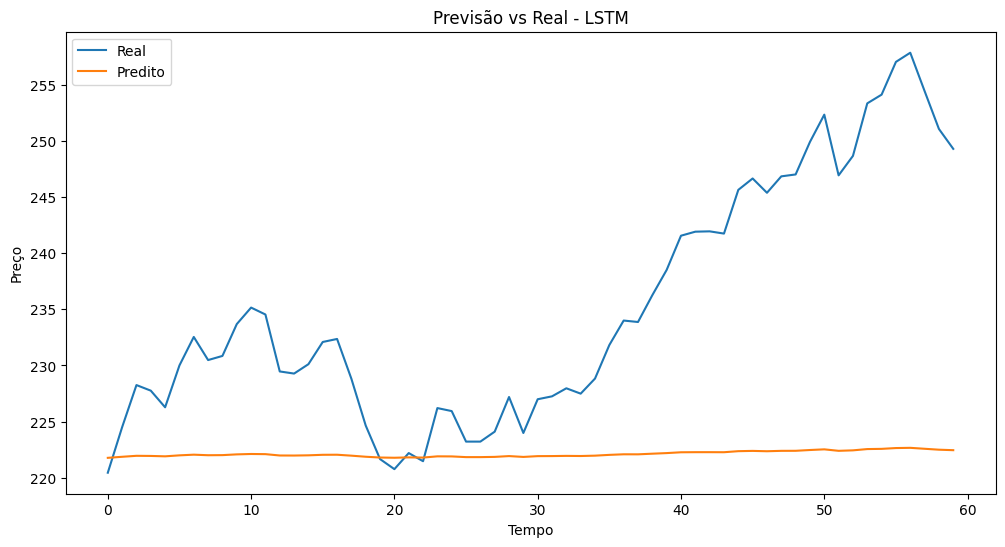

In [23]:
# Comparar previsões com valores reais

plt.figure(figsize=(12,6))
plt.plot(df_test[target_col].values, label='Real')
plt.plot(y_pred, label='Predito')
plt.title('Previsão vs Real - LSTM')
plt.xlabel('Tempo')
plt.ylabel('Preço')
plt.legend()
plt.show()

In [24]:
# Calcular métricas

mae = mean_absolute_error(df_test[target_col], y_pred)
rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))

print(f"MAE: {mae:.5f}")
print(f"RMSE: {rmse:.5f}")

MAE: 13.10643
RMSE: 16.65410


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
MAE: 13.11, RMSE: 16.65


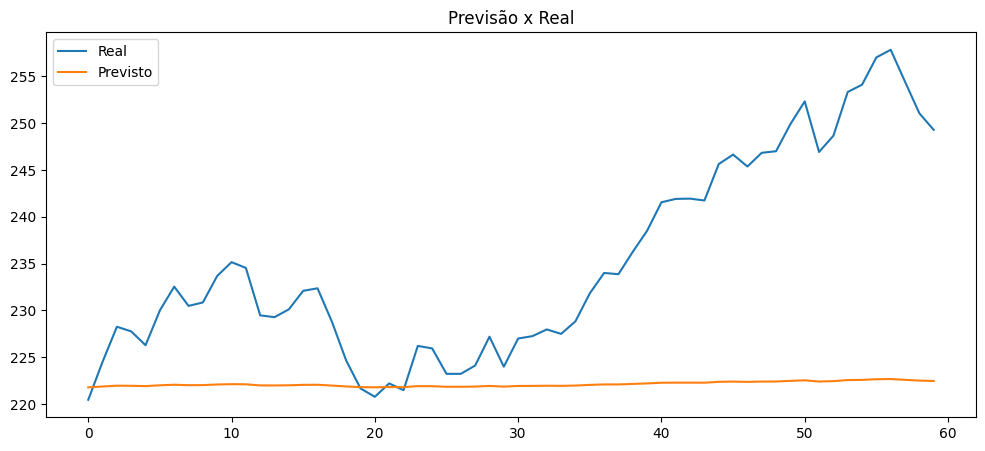

In [25]:
# -----------------------------
# CMD DE NOTEBOOK: VALIDAR SCALER E PREVISÃO
# -----------------------------

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Para o modelo Keras
from tensorflow.keras.models import load_model

# -----------------------------
# 1. Carregar scaler e modelo
# -----------------------------
scaler = joblib.load(SCALER_PATH)
model = load_model(MODEL_PATH)

# -----------------------------
# 2. Preparar dados de teste
# -----------------------------
# Suponha que df_test tenha a coluna 'Close'
X_test = df_test[['Close']].values  # precisa ser 2D

# -----------------------------
# 3. Transformar dados
# -----------------------------
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 4. Prever com o modelo
# -----------------------------
y_pred_scaled = model.predict(X_test_scaled)

# Certifique-se que está em 2D antes de inverter
if y_pred_scaled.ndim == 1:
    y_pred_scaled = y_pred_scaled.reshape(-1, 1)

# -----------------------------
# 5. Inverter escala
# -----------------------------
y_pred = scaler.inverse_transform(y_pred_scaled)

# -----------------------------
# 6. Clipping (opcional, previne extrapolação absurda)
# -----------------------------
y_pred = np.clip(y_pred, scaler.data_min_, scaler.data_max_)

# -----------------------------
# 7. Comparar com valores reais
# -----------------------------
y_true = df_test[['Close']].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# -----------------------------
# 8. Plot (opcional)
# -----------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_true, label='Real')
plt.plot(y_pred, label='Previsto')
plt.title("Previsão x Real")
plt.legend()
plt.show()


In [26]:
y_baseline = df_test['Close'].shift(1).fillna(method='bfill').values
mae_baseline = mean_absolute_error(y_true, y_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_true, y_baseline))
print(f"Baseline MAE: {mae_baseline:.2f}, RMSE: {rmse_baseline:.2f}")


Baseline MAE: 1.96, RMSE: 2.45


C:\Users\mathe\AppData\Local\Temp\ipykernel_24420\1443698508.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_baseline = df_test['Close'].shift(1).fillna(method='bfill').values
